# Image Generation Using Stable Diffusion API

**Author:** [Vijay Sharma]  
**Date:** April 1, 2026  
**Course:** [DSC670- Advance Users of Gen AI]

## Overview
This notebook demonstrates the use of the **official Stability AI API** (https://platform.stability.ai/) to generate and manipulate images through programmatic prompts. We will explore the API's capabilities, generate images using carefully crafted prompts, and evaluate the ease of use and quality of results.

This uses the direct Stability AI API, which is different from accessing it through third-party services like Replicate.

## Setup and Installation

First, I need to install the required libraries to interact with the Stability AI API.

**Requirements:**
1. **Stability AI API Key** - Get from: https://platform.stability.ai/account/keys
2. **Stability SDK** - Official Python SDK for Stability AI

**Available Models:**
- **SDXL 1.0** - Stable Diffusion XL (high quality, 1024x1024)
- **SD 3** - Stable Diffusion 3 (latest model)
- **SD 3.5** - Stable Diffusion 3.5 (newest release)

In [21]:
# Install required packages
%pip install stability-sdk pillow requests python-dotenv matplotlib

Note: you may need to restart the kernel to use updated packages.


In [22]:
# Import required libraries
import os
import io
import warnings
from PIL import Image
import requests
import base64
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import json

# Load environment variables (API keys)
load_dotenv()

print("Libraries imported successfully!")

Libraries imported successfully!


## Configure Stability AI API

Set up your Stability AI API credentials. You can get your API key from https://platform.stability.ai/account/keys

In [23]:
# Stability AI Configuration
STABILITY_API_KEY = os.getenv("STABILITY_API_KEY", "sk-kcCsV40jJDBxLHsLCPsgQLGC8o4WGJpnEYucZYpYOxSF5CBf")
STABILITY_API_HOST = "https://api.stability.ai"

# Available engines/models
# - stable-diffusion-xl-1024-v1-0 (SDXL 1.0)
# - stable-diffusion-v1-6 (SD 1.6)
# - stable-diffusion-512-v2-1 (SD 2.1)
ENGINE_ID = "stable-diffusion-xl-1024-v1-0"  # Using SDXL for best quality

print(f"Stability AI API configured!")
print(f"Engine: {ENGINE_ID}")
print(f"API Host: {STABILITY_API_HOST}")

Stability AI API configured!
Engine: stable-diffusion-xl-1024-v1-0
API Host: https://api.stability.ai


## Define Image Prompts

I've created four distinct prompts that will be used to test Stability AI's capabilities. These prompts are designed to test different aspects of image generation:

1. **Landscape/Environment** - Testing natural scene generation
2. **Character/Portrait** - Testing human/creature rendering
3. **Abstract/Artistic** - Testing creative interpretation
4. **Technical/Architectural** - Testing precision and detail

In [24]:
# Define our four prompts
prompts = {
    "prompt1_landscape": "A serene mountain lake at sunset, with snow-capped peaks reflected in crystal clear water, pine trees in the foreground, vibrant orange and purple sky, photorealistic, 8k quality",
    
    "prompt2_character": "A wise elderly wizard with a long silver beard, wearing deep blue robes embroidered with golden stars, holding a glowing staff, kind eyes, detailed fantasy art style, dramatic lighting",
    
    "prompt3_abstract": "Abstract representation of artificial intelligence: flowing neural networks made of light, geometric patterns, cyan and magenta color palette, digital art, futuristic, high contrast",
    
    "prompt4_architectural": "Modern sustainable architecture: glass and timber eco-house built into a hillside, large windows, green roof with plants, solar panels, minimalist design, architectural photography style"
}

# Display prompts
for key, prompt in prompts.items():
    print(f"\n{key}:")
    print(f"{prompt}")


prompt1_landscape:
A serene mountain lake at sunset, with snow-capped peaks reflected in crystal clear water, pine trees in the foreground, vibrant orange and purple sky, photorealistic, 8k quality

prompt2_character:
A wise elderly wizard with a long silver beard, wearing deep blue robes embroidered with golden stars, holding a glowing staff, kind eyes, detailed fantasy art style, dramatic lighting

prompt3_abstract:
Abstract representation of artificial intelligence: flowing neural networks made of light, geometric patterns, cyan and magenta color palette, digital art, futuristic, high contrast

prompt4_architectural:
Modern sustainable architecture: glass and timber eco-house built into a hillside, large windows, green roof with plants, solar panels, minimalist design, architectural photography style


## Helper Functions

These functions will help us generate and display images using the Stability AI API.

In [25]:
def generate_image_stability(prompt, negative_prompt="", width=1024, height=1024, 
                            cfg_scale=7, steps=30, samples=1, style_preset=None):
    """
    Generate an image using Stability AI API.
    
    Args:
        prompt (str): Text description of the image to generate
        negative_prompt (str): What to avoid in the image
        width (int): Image width (must be multiple of 64)
        height (int): Image height (must be multiple of 64)
        cfg_scale (float): Prompt strength (7-15 typical, higher = more literal)
        steps (int): Inference steps (20-50, more = better quality but slower)
        samples (int): Number of images to generate
        style_preset (str): Optional style preset (e.g., "photographic", "digital-art", "3d-model")
    
    Returns:
        list: List of PIL Image objects
    """
    
    # Prepare the request
    url = f"{STABILITY_API_HOST}/v1/generation/{ENGINE_ID}/text-to-image"
    
    headers = {
        "Content-Type": "application/json",
        "Accept": "application/json",
        "Authorization": f"Bearer {STABILITY_API_KEY}"
    }
    
    body = {
        "text_prompts": [
            {
                "text": prompt,
                "weight": 1
            }
        ],
        "cfg_scale": cfg_scale,
        "height": height,
        "width": width,
        "samples": samples,
        "steps": steps,
    }
    
    # Add negative prompt if provided
    if negative_prompt:
        body["text_prompts"].append({
            "text": negative_prompt,
            "weight": -1
        })
    
    # Add style preset if provided
    if style_preset:
        body["style_preset"] = style_preset
    
    print(f"Generating image with Stability AI...")
    print(f"Steps: {steps}, CFG Scale: {cfg_scale}, Size: {width}x{height}")
    
    # Make the API request
    response = requests.post(url, headers=headers, json=body)
    
    if response.status_code != 200:
        raise Exception(f"Non-200 response: {response.text}")
    
    data = response.json()
    
    # Extract and decode images
    images = []
    for i, artifact in enumerate(data["artifacts"]):
        if artifact["finishReason"] == "SUCCESS":
            img = Image.open(io.BytesIO(base64.b64decode(artifact["base64"])))
            images.append(img)
        else:
            print(f"Warning: Image {i} finished with reason: {artifact['finishReason']}")
    
    print(f"✅ Successfully generated {len(images)} image(s)!")
    return images


def save_image(image, filename):
    """
    Save an image to file.
    
    Args:
        image (PIL.Image): Image to save
        filename (str): Filename to save as
    """
    image.save(filename)
    print(f"Image saved as: {filename}")


def display_image(image, title="Generated Image"):
    """
    Display an image using matplotlib.
    
    Args:
        image (PIL.Image): Image to display
        title (str): Title for the plot
    """
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis('off')
    plt.title(title, fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


print("Helper functions defined successfully!")

Helper functions defined successfully!


## Image Generation with Stability AI

Now I will use Stability AI's official API to generate images from our prompts using SDXL (Stable Diffusion XL).

### Parameters Explained:
- **text_prompts**: Array of prompts with weights (positive and negative)
- **cfg_scale**: Guidance scale - how strictly to follow the prompt (7-15 typical)
- **steps**: Number of diffusion steps (20-50, higher = better quality)
- **width/height**: Image dimensions (must be multiples of 64)
- **samples**: Number of images to generate
- **style_preset**: Optional artistic style (photographic, digital-art, 3d-model, etc.)

### Available Style Presets:
- `photographic` - Photographic style
- `digital-art` - Digital art style
- `3d-model` - 3D render style
- `analog-film` - Film photography
- `cinematic` - Cinematic/movie style
- `fantasy-art` - Fantasy illustration
- `line-art` - Line drawing
- `low-poly` - Low polygon 3D

### Prompt 1: Landscape Generation

GENERATING LANDSCAPE IMAGE

Prompt: A serene mountain lake at sunset, with snow-capped peaks reflected in crystal clear water, pine trees in the foreground, vibrant orange and purple sky, photorealistic, 8k quality

This may take 20-40 seconds...

Generating image with Stability AI...
Steps: 40, CFG Scale: 7, Size: 1024x1024
✅ Successfully generated 1 image(s)!
Image saved as: landscape_stability.png


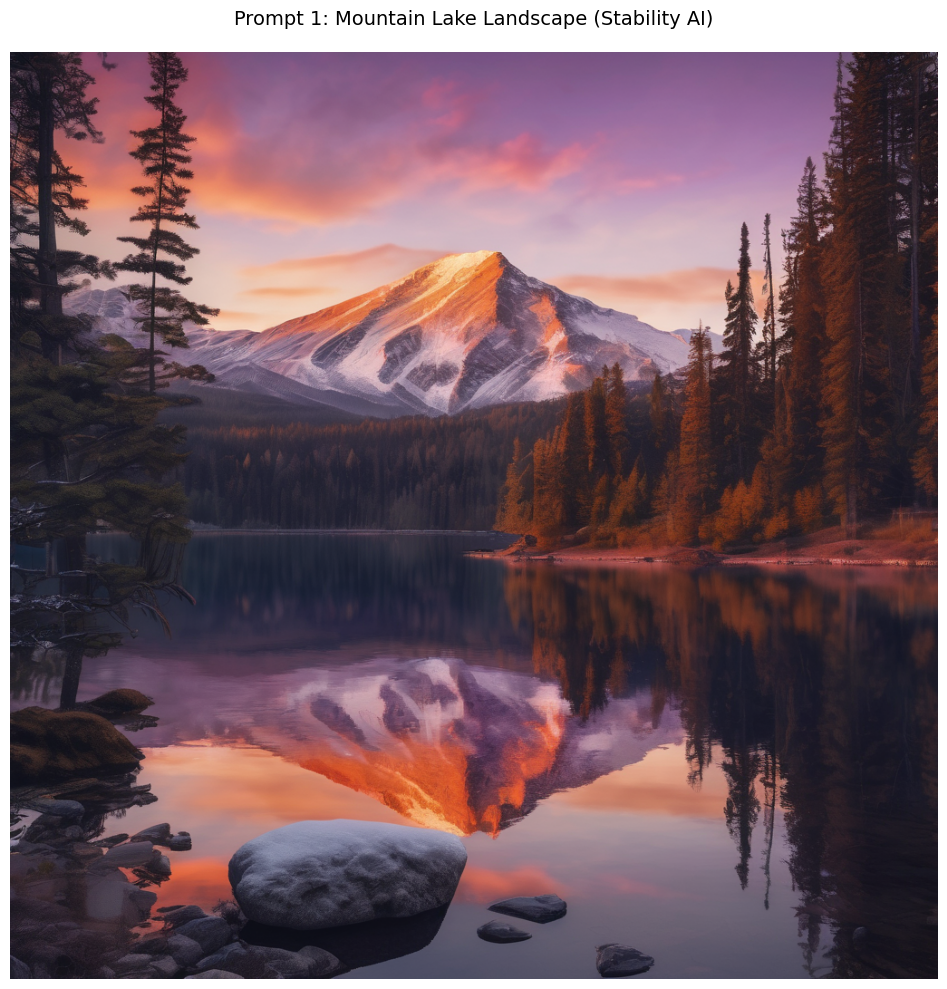

In [26]:
# Generate Image 1: Landscape
print("=" * 80)
print("GENERATING LANDSCAPE IMAGE")
print("=" * 80)
print(f"\nPrompt: {prompts['prompt1_landscape']}")
print("\nThis may take 20-40 seconds...\n")

images1 = generate_image_stability(
    prompt=prompts['prompt1_landscape'],
    negative_prompt="ugly, blurry, low quality, distorted, deformed, watermark",
    width=1024,
    height=1024,
    cfg_scale=7,
    steps=40,
    style_preset="photographic"
)

# Save and display the image
img1 = images1[0]
save_image(img1, "landscape_stability.png")
display_image(img1, "Prompt 1: Mountain Lake Landscape (Stability AI)")

### Prompt 2: Character Generation

GENERATING CHARACTER IMAGE

Prompt: A wise elderly wizard with a long silver beard, wearing deep blue robes embroidered with golden stars, holding a glowing staff, kind eyes, detailed fantasy art style, dramatic lighting

This may take 20-40 seconds...

Generating image with Stability AI...
Steps: 40, CFG Scale: 8, Size: 1024x1024
✅ Successfully generated 1 image(s)!
Image saved as: character_stability.png


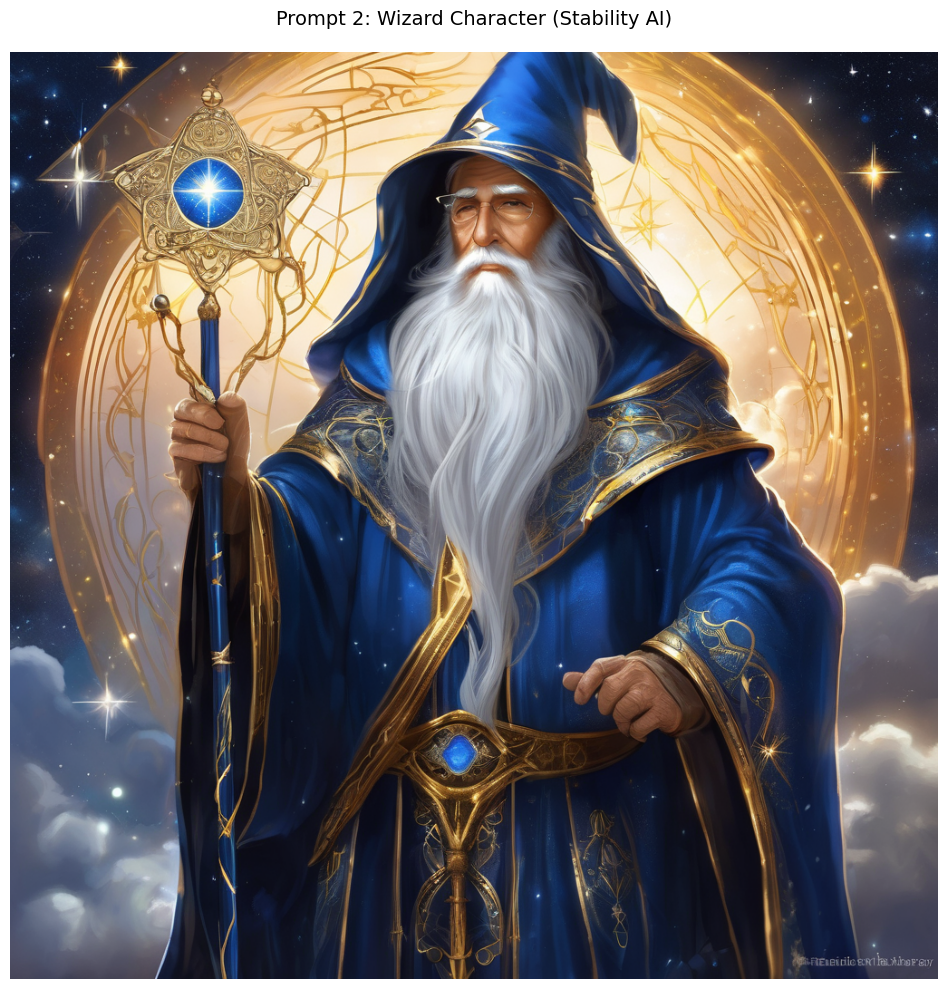

In [30]:
# Generate Image 2: Character
print("=" * 80)
print("GENERATING CHARACTER IMAGE")
print("=" * 80)
print(f"\nPrompt: {prompts['prompt2_character']}")
print("\nThis may take 20-40 seconds...\n")

images2 = generate_image_stability(
    prompt=prompts['prompt2_character'],
    negative_prompt="ugly, distorted face, extra limbs, deformed hands, blurry, low quality, multiple people",
    width=1024,
    height=1024,
    cfg_scale=8,
    steps=40,
    style_preset="fantasy-art"
)

# Save and display the image
img2 = images2[0]
save_image(img2, "character_stability.png")
display_image(img2, "Prompt 2: Wizard Character (Stability AI)")

### Prompt 3: Abstract Art Generation

GENERATING ABSTRACT ART IMAGE

Prompt: Abstract representation of artificial intelligence: flowing neural networks made of light, geometric patterns, cyan and magenta color palette, digital art, futuristic, high contrast

This may take 20-40 seconds...

Generating image with Stability AI...
Steps: 40, CFG Scale: 9, Size: 1024x1024
✅ Successfully generated 1 image(s)!
Image saved as: abstract_stability.png


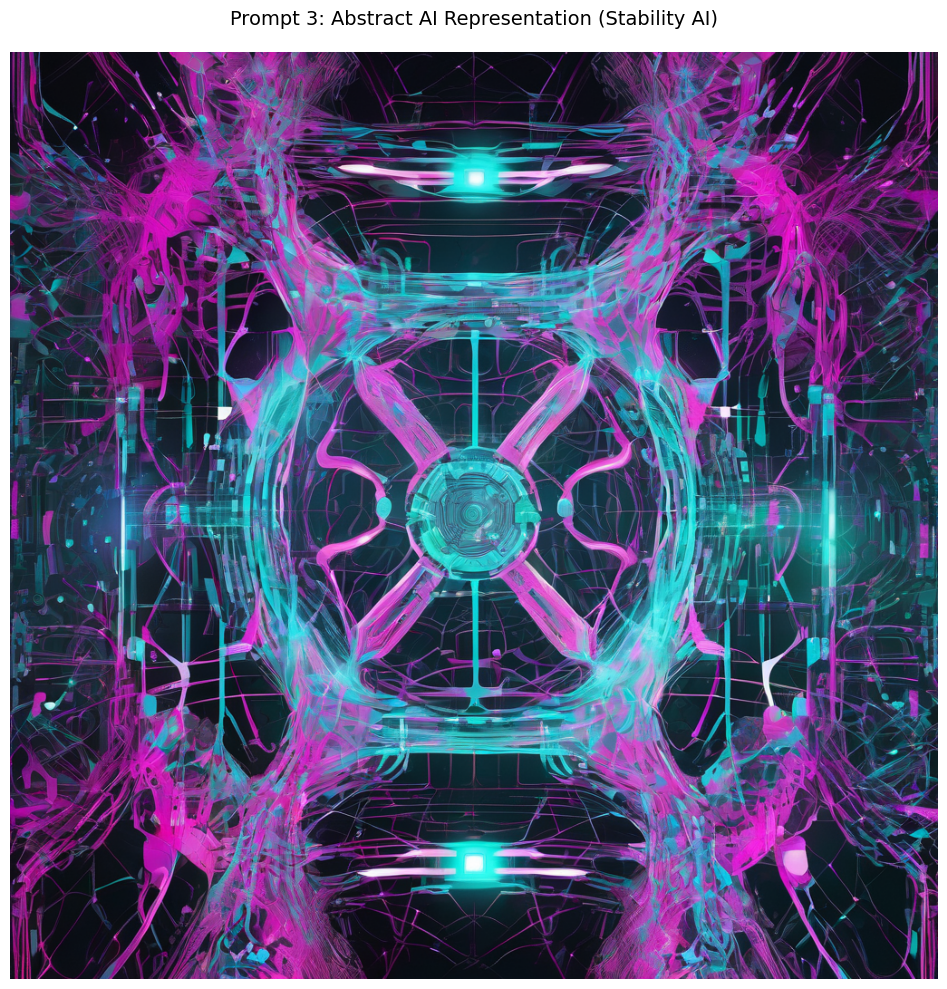

In [31]:
# Generate Image 3: Abstract
print("=" * 80)
print("GENERATING ABSTRACT ART IMAGE")
print("=" * 80)
print(f"\nPrompt: {prompts['prompt3_abstract']}")
print("\nThis may take 20-40 seconds...\n")

images3 = generate_image_stability(
    prompt=prompts['prompt3_abstract'],
    negative_prompt="realistic, photographic, blurry, low quality, dull colors",
    width=1024,
    height=1024,
    cfg_scale=9,
    steps=40,
    style_preset="digital-art"
)

# Save and display the image
img3 = images3[0]
save_image(img3, "abstract_stability.png")
display_image(img3, "Prompt 3: Abstract AI Representation (Stability AI)")

### Prompt 4: Architectural Generation

GENERATING ARCHITECTURAL IMAGE

Prompt: Modern sustainable architecture: glass and timber eco-house built into a hillside, large windows, green roof with plants, solar panels, minimalist design, architectural photography style

This may take 20-40 seconds...

Generating image with Stability AI...
Steps: 40, CFG Scale: 7.5, Size: 1024x1024
✅ Successfully generated 1 image(s)!
Image saved as: architecture_stability.png


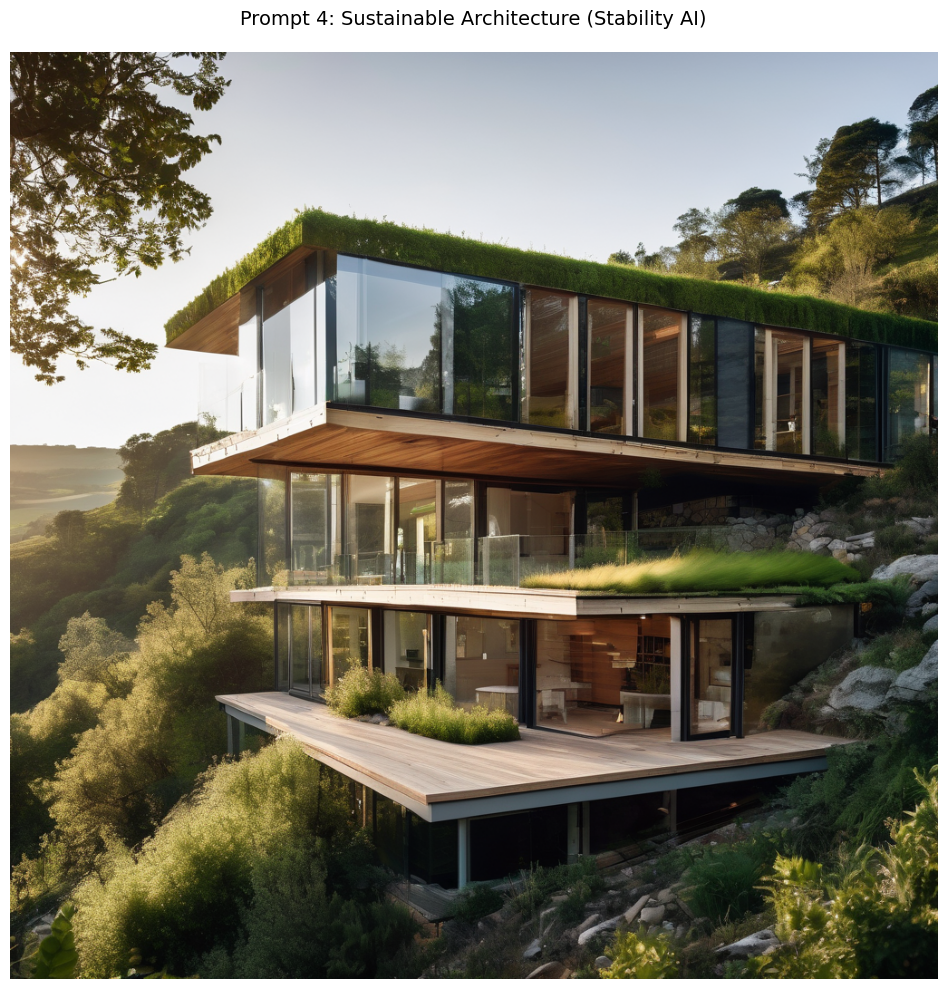

In [29]:
# Generate Image 4: Architecture
print("=" * 80)
print("GENERATING ARCHITECTURAL IMAGE")
print("=" * 80)
print(f"\nPrompt: {prompts['prompt4_architectural']}")
print("\nThis may take 20-40 seconds...\n")

images4 = generate_image_stability(
    prompt=prompts['prompt4_architectural'],
    negative_prompt="ugly, distorted, unrealistic proportions, blurry, low quality, cartoon",
    width=1024,
    height=1024,
    cfg_scale=7.5,
    steps=40,
    style_preset="photographic"
)

# Save and display the image
img4 = images4[0]
save_image(img4, "architecture_stability.png")
display_image(img4, "Prompt 4: Sustainable Architecture (Stability AI)")